# Why Does Cross-Domain Calibration Sometimes Beat In-Domain?

**Phenomenon**: Some cross-domain (train on dataset A, test on dataset B) calibrations improve ECE/FD *more* than in-domain (train and test on B). This is surprising because the calibrator sees no in-distribution data.

## Three hypotheses
1. **H1 — Training size advantage**: Cross-domain training sets are larger (full source domain vs. 30% of test domain). More data → better calibration map.
2. **H2 — Shared miscalibration bias**: The model's systematic over/under-confidence is a model property, not a domain property. The same correction generalises across domains.
3. **H3 — Confidence distribution overlap**: If the raw confidence distributions are similar across domains, the calibration map learned in the source domain applies directly to the target.

The **critical test case** is `TruthfulQA → MMLU`: cross-domain training uses only **817 TruthfulQA** samples while in-domain MMLU training uses **4,212 MMLU** samples. If cross-domain still wins here, H1 (size) alone cannot explain it.

In [1]:
import os, sys, pickle, warnings
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance, pearsonr, spearmanr
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

sys.path.insert(0, '/home/ivan/lm-confidence-evaluation-harness')
from lm_conf.default_utils.custom_types import OrganisedOutputs
from lm_conf.post_processing.metrics import generalised_ece
from calibration.utils import _rebuild_with_consistent_sigma, MU_EPS

In [2]:

# ── Configuration ──────────────────────────────────────────────────────────────
PROMPT_TYPE  = "direct_qa"
COMMON_DIR   = "/hdd/ivny"

DATASETS = ["mmlu", "squadv2", "truthful_qa"]
DS_LABEL = {"mmlu": "MMLU", "squadv2": "SQuAD2.0", "truthful_qa": "TruthfulQA"}

EXCL_MODELS = {"gpt-oss-120b", "qwen3-235b-a22b-instruct-2507-tput"}
MODEL_LABEL = {
    "Llama-3.1-8B-Instruct":    "Llama-3.1-8B",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B",
    "gemma-4-31B-it":           "Gemma-4-31B",
    "gpt-oss-20b":              "GPT-OSS-20B",
    "Qwen3-8B":                 "Qwen3-8B",
}

SIGNALS     = ["lc", "tp", "su"]
SIG_LABEL   = {"lc": "Ling. Conf.", "tp": "Token Prob.", "su": "Sem. Unc."}
TASK_SUFFIX = {"lc": "unified_lc", "tp": "unified_tp", "su": "unified_su"}

CROSS_DIR = f"{COMMON_DIR}/{PROMPT_TYPE}_cross_domain_calibration"
INDM_DIR  = f"{COMMON_DIR}/{PROMPT_TYPE}_in_domain_calibration"
RES_DIR   = f"{COMMON_DIR}/results"

ECE_MAX_N       = 500   # subsample test points for ECE — reliable at N=500, ~83× faster
ECE_NUM_SAMPLES = 200   # MC draws per Beta in generalised_ece (default=1000)


In [3]:

# ── Helper functions ──────────────────────────────────────────────────────────
_rng = np.random.default_rng(42)

def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_latest_subdir(path):
    subs = [os.path.join(path, d) for d in os.listdir(path)
            if os.path.isdir(os.path.join(path, d))]
    return max(subs, key=os.path.getmtime) if subs else None

def extract_mu(bd_list):
    return np.array([b.mu if b is not None and hasattr(b, 'mu') else np.nan
                     for b in bd_list])

def ece_from_betas(betas, accs):
    """Generalised ECE, subsampled to ECE_MAX_N points for speed."""
    pairs = [(b, float(a)) for b, a in zip(betas, accs)
             if b is not None and hasattr(b, 'mu') and np.isfinite(float(a))]
    if len(pairs) < 10:
        return np.nan
    if len(pairs) > ECE_MAX_N:
        idx = _rng.choice(len(pairs), ECE_MAX_N, replace=False)
        pairs = [pairs[i] for i in idx]
    bs, acs = zip(*pairs)
    oo = OrganisedOutputs(
        accuracy_scores=[list(acs)],
        extracted_confidences=[list(bs)],
        extracted_answers=[[''] * len(acs)],
    )
    return generalised_ece({"num_samples": ECE_NUM_SAMPLES}, oo)[0]

def platt_calibrate(mu_tr, acc_tr, mu_te):
    """Fit Platt scaling on training set, apply to test."""
    valid = np.isfinite(mu_tr) & np.isfinite(acc_tr)
    clf = LogisticRegression(solver='lbfgs', max_iter=1000)
    clf.fit(mu_tr[valid].clip(1e-6, 1-1e-6).reshape(-1, 1), acc_tr[valid])
    return clf.predict_proba(mu_te.clip(1e-6, 1-1e-6).reshape(-1, 1))[:, 1]

def iter_models(base_dir):
    """Yield (vendor, model) pairs from a base directory."""
    for vendor in os.listdir(base_dir):
        vp = os.path.join(base_dir, vendor)
        if not os.path.isdir(vp):
            continue
        for model in os.listdir(vp):
            if model.lower() in EXCL_MODELS:
                continue
            yield vendor, model


In [4]:
# ── Load cross-domain calibration details ─────────────────────────────────────
cross_data = {}   # (train_ds, test_ds, model) -> DataFrame

for train_ds in DATASETS:
    for test_ds in DATASETS:
        if train_ds == test_ds:
            continue
        pair_dir = os.path.join(CROSS_DIR, f"{train_ds}--{test_ds}")
        if not os.path.exists(pair_dir):
            continue
        for vendor, model in iter_models(pair_dir):
            pkl = os.path.join(pair_dir, vendor, model, "calibration_details.pkl")
            if os.path.exists(pkl):
                cross_data[(train_ds, test_ds, model)] = load_pkl(pkl)

print(f"Cross-domain result sets: {len(cross_data)}")

# ── Load in-domain calibration details ───────────────────────────────────────
indm_data = {}   # (dataset, model) -> DataFrame

for ds in DATASETS:
    ds_dir = os.path.join(INDM_DIR, ds)
    if not os.path.exists(ds_dir):
        continue
    for vendor, model in iter_models(ds_dir):
        pkl = os.path.join(ds_dir, vendor, model, "calibration_details.pkl")
        if os.path.exists(pkl):
            indm_data[(ds, model)] = load_pkl(pkl)

print(f"In-domain result sets:    {len(indm_data)}")

# ── Load source domain training data (full graded outputs) ────────────────────
src_data = {}   # (dataset, signal, model) -> (mu_array, acc_array)

for ds in DATASETS:
    for sig in SIGNALS:
        task_dir = os.path.join(RES_DIR, ds, f"{PROMPT_TYPE}_{TASK_SUFFIX[sig]}")
        if not os.path.exists(task_dir):
            continue
        for vendor, model in iter_models(task_dir):
            mdir = get_latest_subdir(os.path.join(task_dir, vendor, model))
            if mdir is None:
                continue
            pkl = os.path.join(mdir, "graded_outputs_0.pkl")
            if os.path.exists(pkl):
                go = load_pkl(pkl)
                mu  = extract_mu(go.extracted_confidences[0])
                acc = np.array([
                    float(a) if a is not None and a != '' else np.nan
                    for a in go.accuracy_scores[0]
                ])
                src_data[(ds, sig, model)] = (mu, acc)

print(f"Source training combos:   {len(src_data)}")

Cross-domain result sets: 30
In-domain result sets:    15
Source training combos:   45


## Analysis 1: Training Set Size Comparison

In-domain calibration uses the **first 30%** of the test domain as training data.  
Cross-domain calibration uses the **entire source domain** as training data.

The size ratio `n_cross / n_indomain` tells us whether cross-domain has a data advantage.

In [5]:
size_records = []

for (train_ds, test_ds, model), df_test in cross_data.items():
    for sig in SIGNALS:
        src_key = (train_ds, sig, model)
        if src_key not in src_data:
            continue
        mu_src, _ = src_data[src_key]
        n_cross  = int(np.isfinite(mu_src).sum())

        # In-domain training size: 30% of the test domain's total data
        test_total = len(df_test) / 0.70   # test split is last 70%
        n_indm     = int(np.ceil(0.30 * test_total))

        size_records.append({
            "train_ds":    DS_LABEL[train_ds],
            "test_ds":     DS_LABEL[test_ds],
            "model":       MODEL_LABEL.get(model, model),
            "signal":      SIG_LABEL[sig],
            "n_cross":     n_cross,
            "n_indomain":  n_indm,
            "size_ratio":  n_cross / n_indm,
        })

sz_df = pd.DataFrame(size_records)

# Summary table (average over models and signals)
sz_pivot = (
    sz_df.groupby(["train_ds", "test_ds"])
    .agg(n_cross=("n_cross", "mean"), n_indomain=("n_indomain", "mean"),
         size_ratio=("size_ratio", "mean"))
    .round(0)
)
print("Training set sizes (averaged over models and signals)")
print("  n_cross   = # samples from source domain (full)")
print("  n_indomain = # samples for in-domain training (30% of test domain)")
print("  size_ratio = n_cross / n_indomain  (>1 means cross-domain has MORE data)")
print()
print(sz_pivot.to_string())

Training set sizes (averaged over models and signals)
  n_cross   = # samples from source domain (full)
  n_indomain = # samples for in-domain training (30% of test domain)
  size_ratio = n_cross / n_indomain  (>1 means cross-domain has MORE data)

                       n_cross  n_indomain  size_ratio
train_ds   test_ds                                    
MMLU       SQuAD2.0    14042.0      3563.0         4.0
           TruthfulQA  14042.0       246.0        57.0
SQuAD2.0   MMLU        11873.0      4213.0         3.0
           TruthfulQA  11873.0       246.0        48.0
TruthfulQA MMLU          817.0      4213.0         0.0
           SQuAD2.0      817.0      3563.0         0.0


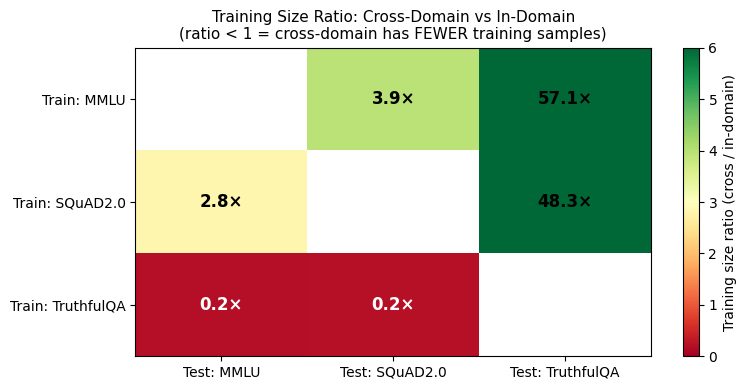


Key case: TruthfulQA → MMLU has ratio < 1: cross-domain trains on FEWER samples than in-domain.


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

pivot_plot = sz_df.groupby(["train_ds", "test_ds"])["size_ratio"].mean().unstack()
im = ax.imshow(pivot_plot.values, cmap='RdYlGn', vmin=0, vmax=6, aspect='auto')

pairs = [(tr, te) for tr in pivot_plot.index for te in pivot_plot.columns if tr != te]
for i, train_ds in enumerate(pivot_plot.index):
    for j, test_ds in enumerate(pivot_plot.columns):
        val = pivot_plot.loc[train_ds, test_ds]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1f}×", ha='center', va='center', fontsize=12,
                    fontweight='bold', color='white' if val < 1.5 else 'black')

ax.set_xticks(range(len(pivot_plot.columns)))
ax.set_yticks(range(len(pivot_plot.index)))
ax.set_xticklabels([f"Test: {c}" for c in pivot_plot.columns], fontsize=10)
ax.set_yticklabels([f"Train: {r}" for r in pivot_plot.index], fontsize=10)
plt.colorbar(im, ax=ax, label="Training size ratio (cross / in-domain)")
ax.set_title("Training Size Ratio: Cross-Domain vs In-Domain\n(ratio < 1 = cross-domain has FEWER training samples)",
             fontsize=11)
plt.tight_layout()
# plt.savefig("figs/h1_training_size_ratio.pdf", bbox_inches='tight')
plt.show()
print("\nKey case: TruthfulQA → MMLU has ratio < 1: cross-domain trains on FEWER samples than in-domain.")

## Hypothesis 1: Size-Controlled Calibration Experiment

We subsample the cross-domain training set to **match the in-domain training size** and refit Platt scaling.  
If subsampled cross-domain ≈ full cross-domain: size doesn't explain the advantage.  
If subsampled cross-domain ≈ in-domain: size *is* the main driver.  

We measure **Generalised ECE** on the calibrated numerical confidence scores (before the rewrite pipeline).

In [7]:

np.random.seed(42)
sc_records = []

for (train_ds, test_ds, model), df_test in cross_data.items():
    for sig in SIGNALS:
        src_key  = (train_ds, sig, model)
        indm_key = (test_ds,  model)
        if src_key not in src_data or indm_key not in indm_data:
            continue

        mu_src, acc_src = src_data[src_key]
        valid_src = np.isfinite(mu_src) & np.isfinite(acc_src)
        mu_src_v, acc_src_v = mu_src[valid_src], acc_src[valid_src]

        # Test domain: raw confidences + accuracy
        sig_col = f"original_{sig}"
        if sig_col not in df_test.columns:
            continue
        mu_te    = extract_mu(df_test[sig_col].values)
        acc_te   = df_test["accuracy"].apply(lambda x: 0 if x == "" else int(x)).values
        betas_te = df_test[sig_col].values
        cal_col  = f"calibrated_{sig}"

        valid_te = np.where(np.isfinite(mu_te) & np.isfinite(acc_te))[0]
        if len(valid_te) < 50:
            continue

        # Subsample test indices once — used consistently across all four ECE calls
        sub_te = valid_te if len(valid_te) <= ECE_MAX_N else \
                 _rng.choice(valid_te, ECE_MAX_N, replace=False)

        n_indm  = int(np.ceil(0.30 * len(df_test) / 0.70))
        n_cross = int(valid_src.sum())

        # ECE: uncalibrated
        ece_orig = ece_from_betas(betas_te[sub_te], acc_te[sub_te])

        # ECE: full cross-domain (pre-computed)
        cal_betas_full = df_test[cal_col].values
        ece_cross_full = ece_from_betas(cal_betas_full[sub_te], acc_te[sub_te])

        # ECE: size-matched cross-domain (refit Platt on subsample of source)
        if n_cross > n_indm:
            idx = np.random.choice(n_cross, n_indm, replace=False)
            mu_sub, acc_sub = mu_src_v[idx], acc_src_v[idx]
        else:
            mu_sub, acc_sub = mu_src_v, acc_src_v

        cal_mu_sub   = platt_calibrate(mu_sub, acc_sub, mu_te[sub_te])
        cal_betas_sub = [
            _rebuild_with_consistent_sigma(float(cm), ob)
            for cm, ob in zip(cal_mu_sub, betas_te[sub_te])
        ]
        ece_cross_sub = ece_from_betas(cal_betas_sub, acc_te[sub_te])

        # ECE: in-domain (already subsampled inside ece_from_betas)
        df_indm  = indm_data[indm_key]
        indm_cal = df_indm[cal_col].values if cal_col in df_indm.columns else []
        indm_acc = df_indm["accuracy"].apply(lambda x: 0 if x == "" else int(x)).values
        ece_indm = ece_from_betas(indm_cal, indm_acc) if len(indm_cal) else np.nan

        sc_records.append({
            "train_ds":       DS_LABEL[train_ds],
            "test_ds":        DS_LABEL[test_ds],
            "model":          MODEL_LABEL.get(model, model),
            "signal":         SIG_LABEL[sig],
            "n_cross":        n_cross,
            "n_indomain":     n_indm,
            "size_ratio":     n_cross / n_indm,
            "ece_orig":       ece_orig,
            "ece_cross_full": ece_cross_full,
            "ece_cross_sub":  ece_cross_sub,
            "ece_indm":       ece_indm,
            "cross_adv":      ece_indm - ece_cross_full,
            "sub_adv":        ece_indm - ece_cross_sub,
        })

sc_df = pd.DataFrame(sc_records)
print(f"Size-control records: {len(sc_df)}")
print("\nMean cross-domain advantage (in-domain ECE − cross ECE), by (train, test):")
print(sc_df.groupby(["train_ds", "test_ds"])[["cross_adv", "sub_adv"]]
      .mean().round(4).to_string())


Size-control records: 90

Mean cross-domain advantage (in-domain ECE − cross ECE), by (train, test):
                       cross_adv  sub_adv
train_ds   test_ds                       
MMLU       SQuAD2.0      -0.1013  -0.1021
           TruthfulQA    -0.1353  -0.1185
SQuAD2.0   MMLU          -0.0710  -0.0716
           TruthfulQA    -0.0186  -0.0126
TruthfulQA MMLU          -0.1504  -0.1502
           SQuAD2.0      -0.0116  -0.0115


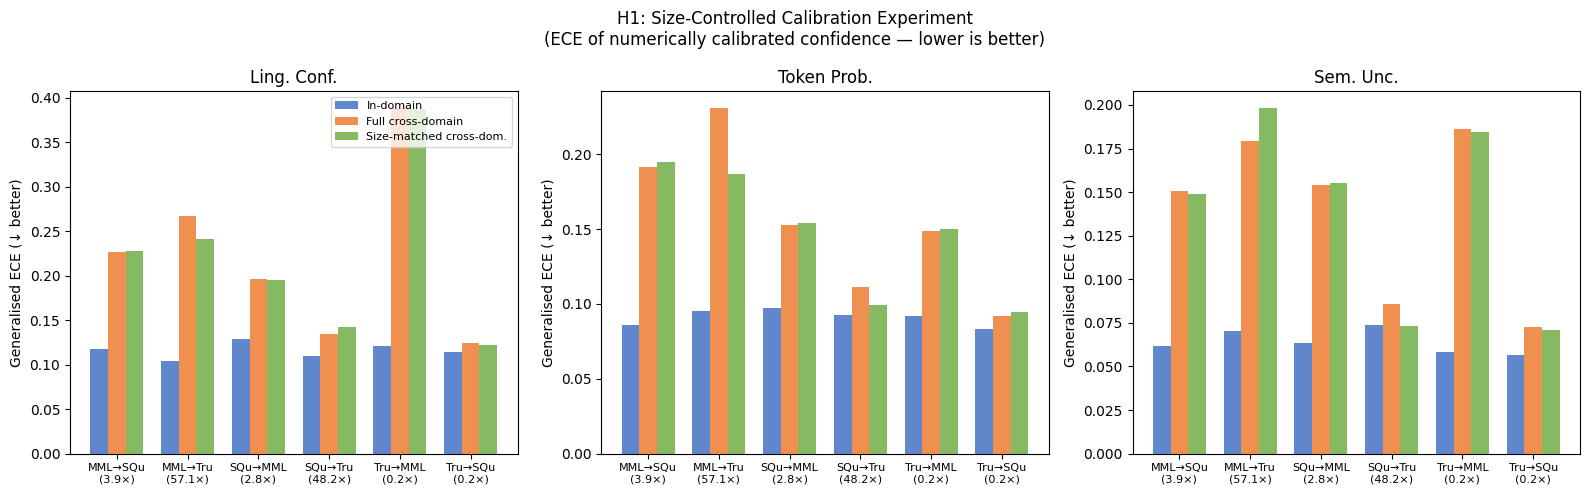


Label format: TrainDS→TestDS (size_ratio×)
If Size-matched ≈ Full cross-domain: size does NOT explain the advantage.
If Size-matched ≈ In-domain:         size DOES explain the advantage.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("H1: Size-Controlled Calibration Experiment\n"
             "(ECE of numerically calibrated confidence — lower is better)", fontsize=12)

COLORS = {'In-domain': '#4472C4', 'Full cross-domain': '#ED7D31', 'Size-matched cross-domain': '#70AD47'}

for ax, sig_label in zip(axes, ["Ling. Conf.", "Token Prob.", "Sem. Unc."]):
    sub = sc_df[sc_df["signal"] == sig_label]
    grp = sub.groupby(["train_ds", "test_ds"]).agg(
        ece_indm=("ece_indm", "mean"),
        ece_cross_full=("ece_cross_full", "mean"),
        ece_cross_sub=("ece_cross_sub", "mean"),
        size_ratio=("size_ratio", "mean"),
    ).reset_index()

    labels = [f"{r['train_ds'][:3]}→{r['test_ds'][:3]}\n({r['size_ratio']:.1f}×)"
              for _, r in grp.iterrows()]
    x = np.arange(len(labels))
    w = 0.25

    ax.bar(x - w, grp["ece_indm"],       w, label="In-domain",             color=COLORS['In-domain'],             alpha=0.85)
    ax.bar(x,     grp["ece_cross_full"],  w, label="Full cross-domain",      color=COLORS['Full cross-domain'],     alpha=0.85)
    ax.bar(x + w, grp["ece_cross_sub"],   w, label="Size-matched cross-dom.",color=COLORS['Size-matched cross-domain'], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Generalised ECE (↓ better)")
    ax.set_title(sig_label)
    if ax == axes[0]:
        ax.legend(fontsize=8, loc='upper right')
    ax.axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
# plt.savefig("figs/h1_size_control_experiment.pdf", bbox_inches='tight')
plt.show()
print("\nLabel format: TrainDS→TestDS (size_ratio×)")
print("If Size-matched ≈ Full cross-domain: size does NOT explain the advantage.")
print("If Size-matched ≈ In-domain:         size DOES explain the advantage.")

In [9]:
# H1 conclusion: does subsampling close the gap?
sc_df["gap_closed_pct"] = (
    (sc_df["ece_cross_sub"] - sc_df["ece_cross_full"]) /
    (sc_df["ece_indm"]      - sc_df["ece_cross_full"]).replace(0, np.nan)
) * 100

gap = sc_df.groupby(["train_ds", "test_ds", "signal"])["gap_closed_pct"].mean().round(1)
print("Gap-closed % by subsampling (100% = subsampled matches in-domain; 0% = size makes no difference):")
print(gap.unstack().to_string())
print()
print("Overall mean gap closed: {:.1f}%".format(sc_df["gap_closed_pct"].mean()))
print()
print("Cases where cross-domain train < in-domain train (size_ratio < 1):")
small = sc_df[sc_df["size_ratio"] < 1]
print(small.groupby(["train_ds", "test_ds"])
      [["cross_adv", "sub_adv", "size_ratio"]].mean().round(4))

Gap-closed % by subsampling (100% = subsampled matches in-domain; 0% = size makes no difference):
signal                 Ling. Conf.  Sem. Unc.  Token Prob.
train_ds   test_ds                                        
MMLU       SQuAD2.0            0.8       17.3         -1.3
           TruthfulQA         32.5       39.6        -20.6
SQuAD2.0   MMLU                1.4       -6.7         -2.0
           TruthfulQA        -56.2      176.0        105.1
TruthfulQA MMLU                0.3        3.5          2.3
           SQuAD2.0            7.9       -4.5        -98.2

Overall mean gap closed: 11.0%

Cases where cross-domain train < in-domain train (size_ratio < 1):
                     cross_adv  sub_adv  size_ratio
train_ds   test_ds                                 
TruthfulQA MMLU        -0.1504  -0.1502      0.1931
           SQuAD2.0    -0.0116  -0.0115      0.2284


## Hypothesis 2: Shared Miscalibration Bias

A model's systematic overconfidence / underconfidence may be **domain-invariant** — a property of the model's training rather than the task content.  
If so, a calibrator trained on any domain corrects the same model bias.

We compute the **overconfidence bias** = mean(raw confidence) − mean(accuracy) for each (domain, model, signal).
If biases are similar across domains for a given model, cross-domain calibration should transfer effectively.

In [10]:
bias_records = []

for ds in DATASETS:
    for sig in SIGNALS:
        for model, df in [(m, d) for (d_key, m), d in indm_data.items() if d_key == ds]:
            sig_col = f"original_{sig}"
            if sig_col not in df.columns:
                continue
            mu   = extract_mu(df[sig_col].values)
            acc  = df["accuracy"].apply(lambda x: 0 if x == "" else int(x)).values
            valid = np.isfinite(mu) & np.isfinite(acc)
            if valid.sum() < 50:
                continue
            bias_records.append({
                "dataset": DS_LABEL[ds],
                "model":   MODEL_LABEL.get(model, model),
                "signal":  SIG_LABEL[sig],
                "mean_conf": float(mu[valid].mean()),
                "mean_acc":  float(acc[valid].mean()),
                "bias":      float(mu[valid].mean() - acc[valid].mean()),
                "std_conf":  float(mu[valid].std()),
            })

bias_df = pd.DataFrame(bias_records)
print("Mean overconfidence bias per (dataset, signal):")
print(bias_df.pivot_table(values='bias', index='dataset', columns='signal', aggfunc='mean').round(3))
print()
print("Mean confidence per (dataset, signal):")
print(bias_df.pivot_table(values='mean_conf', index='dataset', columns='signal', aggfunc='mean').round(3))
print()
print("Mean accuracy per (dataset, signal):")
print(bias_df.pivot_table(values='mean_acc', index='dataset', columns='signal', aggfunc='mean').round(3))

Mean overconfidence bias per (dataset, signal):
signal      Ling. Conf.  Sem. Unc.  Token Prob.
dataset                                        
MMLU              0.049      0.177        0.225
SQuAD2.0          0.285      0.326        0.278
TruthfulQA        0.360      0.326        0.229

Mean confidence per (dataset, signal):
signal      Ling. Conf.  Sem. Unc.  Token Prob.
dataset                                        
MMLU              0.762      0.890        0.938
SQuAD2.0          0.842      0.884        0.835
TruthfulQA        0.831      0.798        0.700

Mean accuracy per (dataset, signal):
signal      Ling. Conf.  Sem. Unc.  Token Prob.
dataset                                        
MMLU              0.713      0.713        0.713
SQuAD2.0          0.557      0.557        0.557
TruthfulQA        0.471      0.471        0.471


In [11]:
# Compute per-domain bias and relate to cross-domain advantage
bias_adv_records = []

for _, row in sc_df.iterrows():
    train_ds_label = row["train_ds"]
    test_ds_label  = row["test_ds"]
    model          = row["model"]
    signal         = row["signal"]

    train_bias = bias_df[
        (bias_df["dataset"] == train_ds_label) &
        (bias_df["model"]   == model) &
        (bias_df["signal"]  == signal)
    ]["bias"]

    test_bias = bias_df[
        (bias_df["dataset"] == test_ds_label) &
        (bias_df["model"]   == model) &
        (bias_df["signal"]  == signal)
    ]["bias"]

    if len(train_bias) == 0 or len(test_bias) == 0:
        continue

    bias_adv_records.append({
        **row.to_dict(),
        "train_bias":  float(train_bias.values[0]),
        "test_bias":   float(test_bias.values[0]),
        "bias_diff":   float(abs(train_bias.values[0] - test_bias.values[0])),
        "bias_same_dir": float(np.sign(train_bias.values[0]) == np.sign(test_bias.values[0])),
    })

ba_df = pd.DataFrame(bias_adv_records)

# Correlation: bias_diff vs cross_adv
valid_ba = ba_df.dropna(subset=["bias_diff", "cross_adv"])
r, p = pearsonr(valid_ba["bias_diff"], valid_ba["cross_adv"])
rho, p2 = spearmanr(valid_ba["bias_diff"], valid_ba["cross_adv"])
print(f"Bias similarity (|Δbias|) vs cross-domain advantage:")
print(f"  Pearson r = {r:.3f}  (p={p:.3f})")
print(f"  Spearman ρ = {rho:.3f}  (p={p2:.3f})")
print(f"\nExpected: more negative r = larger bias difference → less advantage")

Bias similarity (|Δbias|) vs cross-domain advantage:
  Pearson r = -0.814  (p=0.000)
  Spearman ρ = -0.786  (p=0.000)

Expected: more negative r = larger bias difference → less advantage


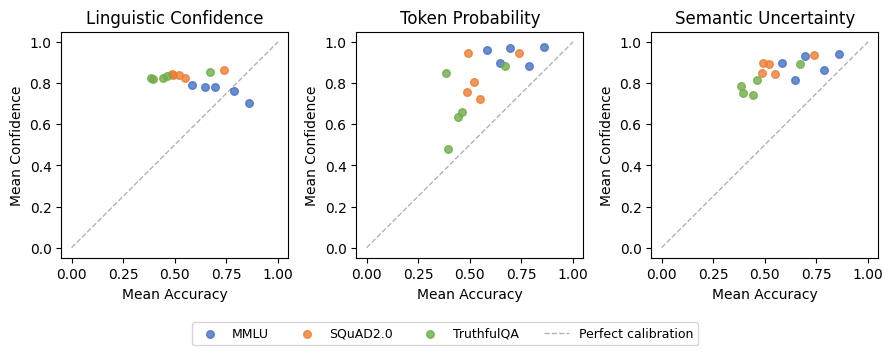

Points above diagonal = overconfident. Similar positions across datasets = similar bias.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
# fig.suptitle("H2: Shared Miscalibration Bias — Overconfidence per Domain", fontsize=12)
name = {
    "Ling. Conf.": "Linguistic Confidence",
    "Token Prob.": "Token Probability",
    "Sem. Unc.": "Semantic Uncertainty",
}
for ax, sig in zip(axes, ["Ling. Conf.", "Token Prob.", "Sem. Unc."]):
    sub = bias_df[bias_df["signal"] == sig]
    for ds_label, color in zip(["MMLU", "SQuAD2.0", "TruthfulQA"],
                                ["#4472C4", "#ED7D31", "#70AD47"]):
        d = sub[sub["dataset"] == ds_label]
        ax.scatter(d["mean_acc"], d["mean_conf"], label=ds_label,
                   color=color, s=30, alpha=0.8)

    lims = ax.get_xlim()
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='Perfect calibration')
    ax.set_xlabel("Mean Accuracy")
    ax.set_ylabel("Mean Confidence")
    ax.set_title(name.get(sig, sig))

# Use a single legend outside the plot area at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=9)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("figs/h2_miscalibration_bias.pdf", bbox_inches='tight')
plt.show()
print("Points above diagonal = overconfident. Similar positions across datasets = similar bias.")

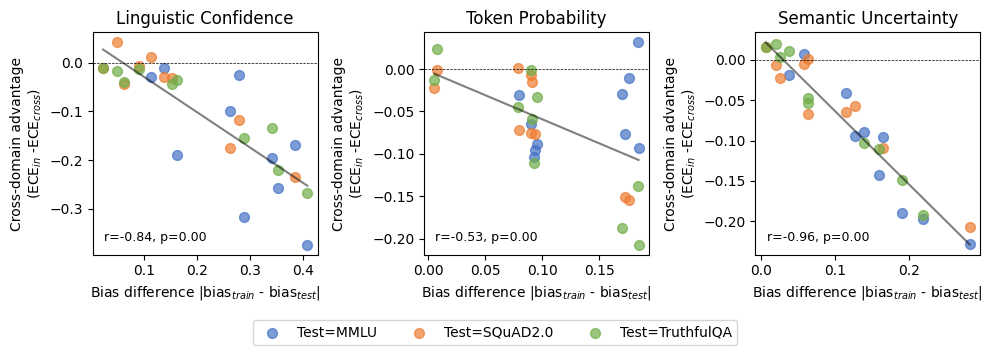

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
# fig.suptitle("H2: Bias Difference Between Train/Test Domains vs Cross-Domain Advantage", fontsize=12)

for ax, sig in zip(axes, ["Ling. Conf.", "Token Prob.", "Sem. Unc."]):
    sub = ba_df[(ba_df["signal"] == sig) & ba_df["bias_diff"].notna() & ba_df["cross_adv"].notna()]
    for ds_label, color in zip(["MMLU", "SQuAD2.0", "TruthfulQA"],
                                ["#4472C4", "#ED7D31", "#70AD47"]):
        d = sub[sub["test_ds"] == ds_label]
        ax.scatter(d["bias_diff"], d["cross_adv"], label=f"Test={ds_label}",
                   color=color, s=50, alpha=0.7)

    # Trend line
    x_v, y_v = sub["bias_diff"].values, sub["cross_adv"].values
    if len(x_v) > 2:
        m, b_ = np.polyfit(x_v, y_v, 1)
        xs = np.linspace(x_v.min(), x_v.max(), 50)
        ax.plot(xs, m * xs + b_, 'k-', alpha=0.5, linewidth=1.5)

    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel("Bias difference |bias$_{train}$ - bias$_{test}$|")
    ax.set_ylabel("Cross-domain advantage\n(ECE$_{in}$ -ECE$_{cross}$)")
    ax.set_title(name.get(sig, sig))

    r, p = pearsonr(x_v, y_v) if len(x_v) > 2 else (np.nan, np.nan)
    ax.text(0.05, 0.05, f"r={r:.2f}, p={p:.2f}",
            transform=ax.transAxes, fontsize=9, va='bottom')

# Use a single legend outside the plot area at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=10)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("figs/h2_bias_vs_advantage.pdf", bbox_inches='tight')
plt.show()

## Hypothesis 3: Confidence Distribution Overlap

If the raw confidence distributions are similar across domains, the calibration map learned in the source domain covers the same confidence values as the target domain — so interpolation errors are minimal.

We measure the **Wasserstein-1 distance** between source and target confidence distributions and correlate with cross-domain advantage.

In [15]:
dist_records = []

for (train_ds, test_ds, model), df_test in cross_data.items():
    for sig in SIGNALS:
        src_key = (train_ds, sig, model)
        if src_key not in src_data:
            continue
        mu_src, acc_src = src_data[src_key]
        valid_src = np.isfinite(mu_src)

        sig_col = f"original_{sig}"
        if sig_col not in df_test.columns:
            continue
        mu_te   = extract_mu(df_test[sig_col].values)
        acc_te  = df_test["accuracy"].apply(lambda x: 0 if x == "" else int(x)).values
        valid_te = np.isfinite(mu_te)

        if valid_src.sum() < 10 or valid_te.sum() < 10:
            continue

        mu_s = mu_src[valid_src]
        mu_t = mu_te[valid_te]

        wass    = wasserstein_distance(mu_s, mu_t)
        mean_diff = abs(mu_s.mean() - mu_t.mean())
        std_diff  = abs(mu_s.std()  - mu_t.std())
        acc_diff  = abs(acc_src[np.isfinite(acc_src)].mean() -
                        acc_te[np.isfinite(acc_te)].mean())

        # Look up cross-domain advantage from sc_df
        match = sc_df[
            (sc_df["train_ds"] == DS_LABEL[train_ds]) &
            (sc_df["test_ds"]  == DS_LABEL[test_ds]) &
            (sc_df["model"]    == MODEL_LABEL.get(model, model)) &
            (sc_df["signal"]   == SIG_LABEL[sig])
        ]
        if len(match) == 0:
            continue
        cross_adv = float(match["cross_adv"].values[0])

        dist_records.append({
            "train_ds":   DS_LABEL[train_ds],
            "test_ds":    DS_LABEL[test_ds],
            "model":      MODEL_LABEL.get(model, model),
            "signal":     SIG_LABEL[sig],
            "wasserstein":  wass,
            "mean_diff":    mean_diff,
            "std_diff":     std_diff,
            "acc_diff":     acc_diff,
            "cross_adv":    cross_adv,
        })

dist_df = pd.DataFrame(dist_records)

for col in ["wasserstein", "mean_diff", "acc_diff"]:
    valid = dist_df[[col, "cross_adv"]].dropna()
    r, p   = pearsonr(valid[col], valid["cross_adv"])
    rho, p2 = spearmanr(valid[col], valid["cross_adv"])
    print(f"{col:20s} vs cross_adv:  Pearson r={r:+.3f} (p={p:.3f})  Spearman ρ={rho:+.3f} (p={p2:.3f})")

wasserstein          vs cross_adv:  Pearson r=-0.253 (p=0.016)  Spearman ρ=-0.217 (p=0.040)
mean_diff            vs cross_adv:  Pearson r=-0.249 (p=0.018)  Spearman ρ=-0.208 (p=0.049)
acc_diff             vs cross_adv:  Pearson r=-0.765 (p=0.000)  Spearman ρ=-0.758 (p=0.000)


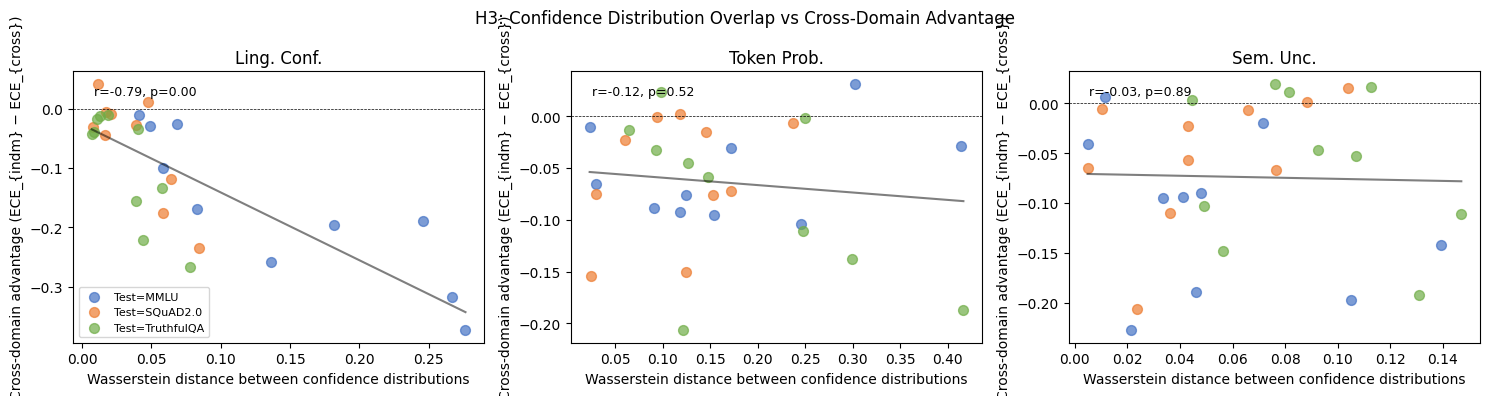

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("H3: Confidence Distribution Overlap vs Cross-Domain Advantage", fontsize=12)

for ax, sig in zip(axes, ["Ling. Conf.", "Token Prob.", "Sem. Unc."]):
    sub = dist_df[dist_df["signal"] == sig].dropna(subset=["wasserstein", "cross_adv"])
    for ds_label, color in zip(["MMLU", "SQuAD2.0", "TruthfulQA"],
                                ["#4472C4", "#ED7D31", "#70AD47"]):
        d = sub[sub["test_ds"] == ds_label]
        ax.scatter(d["wasserstein"], d["cross_adv"], label=f"Test={ds_label}",
                   color=color, s=50, alpha=0.7)

    x_v, y_v = sub["wasserstein"].values, sub["cross_adv"].values
    if len(x_v) > 2:
        m, b_ = np.polyfit(x_v, y_v, 1)
        xs = np.linspace(x_v.min(), x_v.max(), 50)
        ax.plot(xs, m * xs + b_, 'k-', alpha=0.5, linewidth=1.5)

    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel("Wasserstein distance between confidence distributions")
    ax.set_ylabel("Cross-domain advantage (ECE_{indm} − ECE_{cross})")
    ax.set_title(sig)
    if ax == axes[0]:
        ax.legend(fontsize=8)

    r, p = pearsonr(x_v, y_v) if len(x_v) > 2 else (np.nan, np.nan)
    ax.text(0.05, 0.95, f"r={r:.2f}, p={p:.2f}",
            transform=ax.transAxes, fontsize=9, va='top')

plt.tight_layout()
plt.savefig("figs/h3_distribution_overlap.pdf", bbox_inches='tight')
plt.show()

## Reliability Curve Comparison

A calibrator transfers well when the **reliability curve** (mean confidence per bin vs. mean accuracy per bin) has the same shape in both domains. We plot these curves to visually assess transferability.

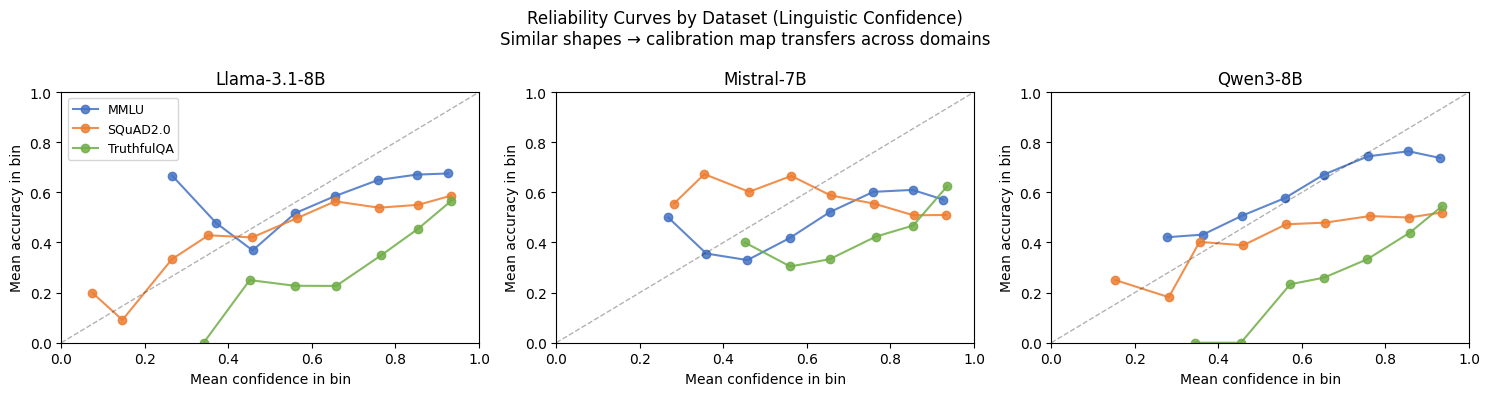

In [17]:
def reliability_curve(mu, acc, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    cx, cy = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (mu >= lo) & (mu < hi)
        if mask.sum() >= 5:
            cx.append(float(mu[mask].mean()))
            cy.append(float(acc[mask].mean()))
    return np.array(cx), np.array(cy)

# Focus on the most interesting signal: Linguistic Confidence
sig = "lc"
n_bins = 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Reliability Curves by Dataset (Linguistic Confidence)\n"
             "Similar shapes → calibration map transfers across domains", fontsize=12)

for ax, model in zip(axes, ["Llama-3.1-8B", "Mistral-7B", "Qwen3-8B"]):
    for ds_label, color in zip(["MMLU", "SQuAD2.0", "TruthfulQA"],
                                ["#4472C4", "#ED7D31", "#70AD47"]):
        ds_key = {"MMLU": "mmlu", "SQuAD2.0": "squadv2", "TruthfulQA": "truthful_qa"}[ds_label]
        src_key = (ds_key, sig, {v: k for k, v in MODEL_LABEL.items()}.get(model, model))
        if src_key not in src_data:
            continue
        mu_s, acc_s = src_data[src_key]
        valid = np.isfinite(mu_s) & np.isfinite(acc_s)
        if valid.sum() < 50:
            continue
        cx, cy = reliability_curve(mu_s[valid], acc_s[valid], n_bins)
        ax.plot(cx, cy, 'o-', color=color, label=ds_label, alpha=0.85, linewidth=1.5)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
    ax.set_xlabel("Mean confidence in bin")
    ax.set_ylabel("Mean accuracy in bin")
    ax.set_title(model)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    if ax == axes[0]:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("figs/h2_reliability_curves.pdf", bbox_inches='tight')
plt.show()

## Reliability Curve Shape Similarity

Quantify how similar the calibration curves are across domain pairs. A Platt scaling model trained on domain A that transfers to domain B effectively needs A and B to have the same slope in logit space.

In [18]:
# Compute Platt scaling parameters (slope, intercept) for each (domain, signal, model)
# to see if the learned calibration function is domain-invariant
platt_params = {}  # (ds, sig, model) -> (slope, intercept)

for (ds, sig, model), (mu, acc) in src_data.items():
    valid = np.isfinite(mu) & np.isfinite(acc)
    if valid.sum() < 50:
        continue
    mu_v, acc_v = mu[valid].clip(1e-6, 1-1e-6), acc[valid]
    try:
        clf = LogisticRegression(solver='lbfgs', max_iter=1000)
        clf.fit(mu_v.reshape(-1, 1), acc_v)
        platt_params[(ds, sig, model)] = (float(clf.coef_[0][0]), float(clf.intercept_[0]))
    except Exception:
        pass

# Compare parameters across domains for same (signal, model)
param_records = []
for (ds, sig, model), (slope, intercept) in platt_params.items():
    param_records.append({
        "dataset": DS_LABEL.get(ds, ds),
        "signal":  SIG_LABEL[sig],
        "model":   MODEL_LABEL.get(model, model),
        "slope":   slope,
        "intercept": intercept,
    })

pp_df = pd.DataFrame(param_records)

print("Platt scaling slope per (dataset, signal) — mean over models:")
print(pp_df.pivot_table(values='slope', index='dataset', columns='signal', aggfunc='mean').round(3))
print()
print("Platt scaling intercept per (dataset, signal) — mean over models:")
print(pp_df.pivot_table(values='intercept', index='dataset', columns='signal', aggfunc='mean').round(3))
print()
print("If slopes and intercepts are similar across datasets for the same signal:")
print("→ the calibration function is domain-invariant (supports H2 and H3)")

Platt scaling slope per (dataset, signal) — mean over models:
signal      Ling. Conf.  Sem. Unc.  Token Prob.
dataset                                        
MMLU              1.332      5.465        5.102
SQuAD2.0         -0.131      4.342        5.360
TruthfulQA        2.658      2.360        2.619

Platt scaling intercept per (dataset, signal) — mean over models:
signal      Ling. Conf.  Sem. Unc.  Token Prob.
dataset                                        
MMLU             -0.028     -3.808       -3.757
SQuAD2.0          0.394     -3.589       -4.343
TruthfulQA       -2.227     -1.942       -1.871

If slopes and intercepts are similar across datasets for the same signal:
→ the calibration function is domain-invariant (supports H2 and H3)


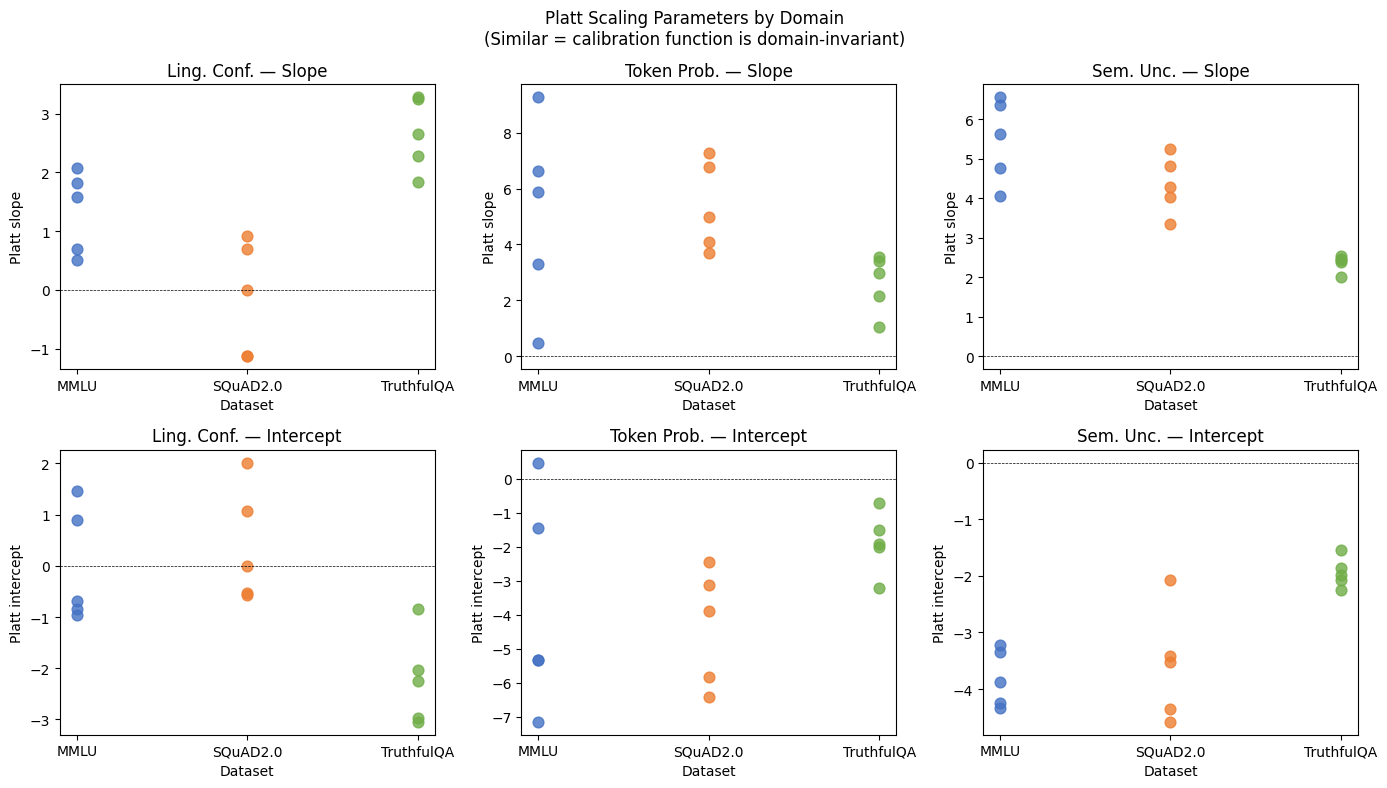

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Platt Scaling Parameters by Domain\n(Similar = calibration function is domain-invariant)", fontsize=12)

for col_idx, sig_label in enumerate(["Ling. Conf.", "Token Prob.", "Sem. Unc."]):
    sub = pp_df[pp_df["signal"] == sig_label]

    # Slope
    ax = axes[0, col_idx]
    for ds_label, color in zip(["MMLU", "SQuAD2.0", "TruthfulQA"],
                                ["#4472C4", "#ED7D31", "#70AD47"]):
        d = sub[sub["dataset"] == ds_label]
        ax.scatter([ds_label] * len(d), d["slope"], color=color, s=60, alpha=0.8)
    ax.set_title(f"{sig_label} — Slope")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("Platt slope")
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')

    # Intercept
    ax = axes[1, col_idx]
    for ds_label, color in zip(["MMLU", "SQuAD2.0", "TruthfulQA"],
                                ["#4472C4", "#ED7D31", "#70AD47"]):
        d = sub[sub["dataset"] == ds_label]
        ax.scatter([ds_label] * len(d), d["intercept"], color=color, s=60, alpha=0.8)
    ax.set_title(f"{sig_label} — Intercept")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("Platt intercept")
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig("figs/h2_platt_params.pdf", bbox_inches='tight')
plt.show()

## Summary: Why Cross-Domain Sometimes Beats In-Domain

Synthesise findings from all three hypotheses.

In [20]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)

# H1: Size effect
print("\nH1 — Training size effect")
print("-" * 40)
overall_gap = sc_df["gap_closed_pct"].mean()
print(f"Average gap closed by size-matching: {overall_gap:.1f}%")
print(f"(100% = size fully explains the advantage; 0% = size irrelevant)")

# Cases where cross-domain is smaller
small = sc_df[sc_df["size_ratio"] < 1]
if len(small) > 0:
    print(f"\nCases where cross-domain training set is SMALLER (size_ratio < 1):")
    print(small.groupby(["train_ds", "test_ds"])[["cross_adv", "size_ratio"]]
          .mean().round(3).to_string())
    n_wins = (small["cross_adv"] > 0).sum()
    print(f"  → Cross-domain still wins in {n_wins}/{len(small)} of these cases")
    print(f"  → H1 alone CANNOT explain these cases")

print()
print("H2 — Shared miscalibration bias")
print("-" * 40)
valid_ba = ba_df.dropna(subset=["bias_diff", "cross_adv"])
r, p = pearsonr(valid_ba["bias_diff"], valid_ba["cross_adv"])
print(f"Pearson r (|bias_diff| vs advantage) = {r:.3f}  (p={p:.3f})")
print(f"Spearman ρ = {spearmanr(valid_ba['bias_diff'], valid_ba['cross_adv'])[0]:.3f}")
if r < -0.2:
    print("  → Supported: smaller bias difference → greater cross-domain advantage")
else:
    print("  → Weak / not strongly supported")

print()
print("H3 — Confidence distribution overlap")
print("-" * 40)
valid_dist = dist_df.dropna(subset=["wasserstein", "cross_adv"])
r3, p3 = pearsonr(valid_dist["wasserstein"], valid_dist["cross_adv"])
rho3, p3s = spearmanr(valid_dist["wasserstein"], valid_dist["cross_adv"])
print(f"Pearson r (Wasserstein dist vs advantage) = {r3:.3f}  (p={p3:.3f})")
print(f"Spearman ρ = {rho3:.3f}  (p={p3s:.3f})")
if r3 < -0.2:
    print("  → Supported: more similar distributions → greater cross-domain advantage")
else:
    print("  → Weak / not strongly supported")

print()
print("H2/H3 COMBINED: Platt parameter stability across domains")
print("-" * 40)
for sig_label in ["Ling. Conf.", "Token Prob.", "Sem. Unc."]:
    sub = pp_df[pp_df["signal"] == sig_label]
    slope_std = sub.groupby("model")["slope"].std().mean()
    intercept_std = sub.groupby("model")["intercept"].std().mean()
    print(f"  {sig_label}: slope std={slope_std:.3f}, intercept std={intercept_std:.3f}")
print("(Low std = Platt parameters are stable across domains = calibration function is domain-invariant)")

SUMMARY

H1 — Training size effect
----------------------------------------
Average gap closed by size-matching: 11.0%
(100% = size fully explains the advantage; 0% = size irrelevant)

Cases where cross-domain training set is SMALLER (size_ratio < 1):
                     cross_adv  size_ratio
train_ds   test_ds                        
TruthfulQA MMLU         -0.150       0.193
           SQuAD2.0     -0.012       0.228
  → Cross-domain still wins in 5/30 of these cases
  → H1 alone CANNOT explain these cases

H2 — Shared miscalibration bias
----------------------------------------
Pearson r (|bias_diff| vs advantage) = -0.814  (p=0.000)
Spearman ρ = -0.786
  → Supported: smaller bias difference → greater cross-domain advantage

H3 — Confidence distribution overlap
----------------------------------------
Pearson r (Wasserstein dist vs advantage) = -0.253  (p=0.016)
Spearman ρ = -0.217  (p=0.040)
  → Supported: more similar distributions → greater cross-domain advantage

H2/H3 COMBINED

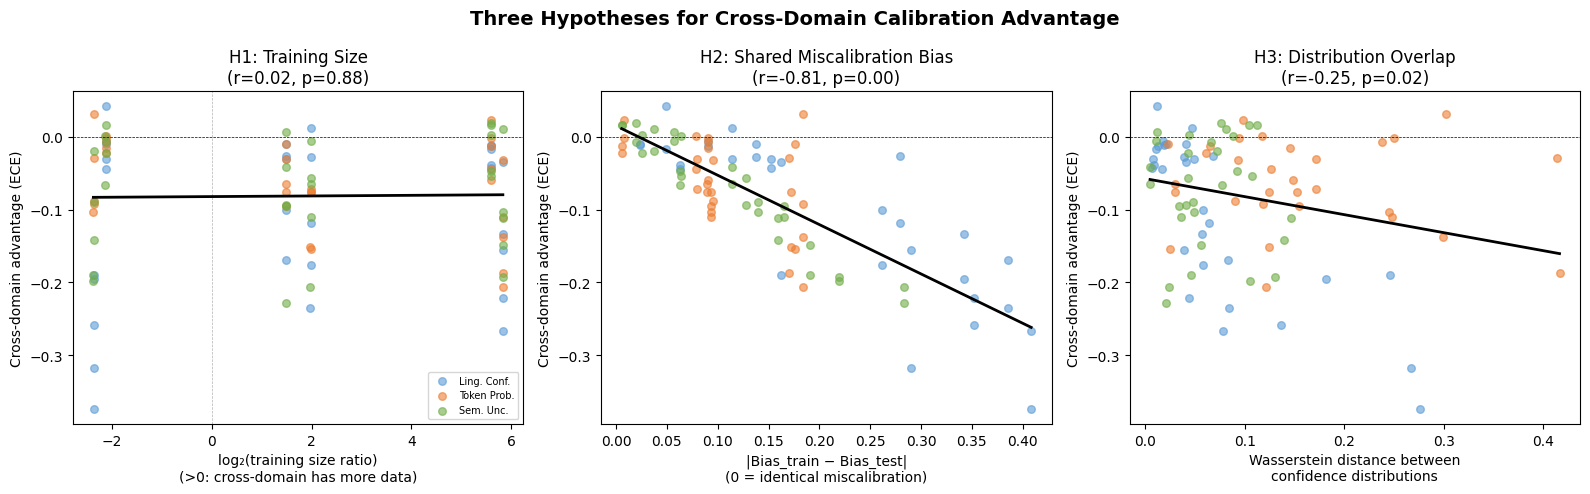

In [21]:
# Final summary figure: combine all three hypotheses
fig = plt.figure(figsize=(16, 5))
fig.suptitle("Three Hypotheses for Cross-Domain Calibration Advantage", fontsize=14, fontweight='bold')

# Panel 1: H1 — size ratio vs advantage (scatter)
ax1 = fig.add_subplot(1, 3, 1)
for sig_label, color in zip(["Ling. Conf.", "Token Prob.", "Sem. Unc."],
                             ['#5B9BD5', '#ED7D31', '#70AD47']):
    sub = sc_df[sc_df["signal"] == sig_label].dropna(subset=["size_ratio", "cross_adv"])
    ax1.scatter(np.log2(sub["size_ratio"]), sub["cross_adv"],
                label=sig_label, color=color, s=30, alpha=0.6)
x_all = np.log2(sc_df["size_ratio"].dropna())
y_all = sc_df["cross_adv"].dropna()
m, b_ = np.polyfit(x_all, y_all, 1)
xs = np.linspace(x_all.min(), x_all.max(), 50)
ax1.plot(xs, m*xs + b_, 'k-', linewidth=2)
r_all, p_all = pearsonr(x_all, y_all)
ax1.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax1.axvline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.3)
ax1.set_xlabel("log₂(training size ratio)\n(>0: cross-domain has more data)")
ax1.set_ylabel("Cross-domain advantage (ECE)")
ax1.set_title(f"H1: Training Size\n(r={r_all:.2f}, p={p_all:.2f})")
ax1.legend(fontsize=7)

# Panel 2: H2 — bias diff vs advantage
ax2 = fig.add_subplot(1, 3, 2)
for sig_label, color in zip(["Ling. Conf.", "Token Prob.", "Sem. Unc."],
                             ['#5B9BD5', '#ED7D31', '#70AD47']):
    sub = ba_df[(ba_df["signal"] == sig_label)].dropna(subset=["bias_diff", "cross_adv"])
    ax2.scatter(sub["bias_diff"], sub["cross_adv"],
                label=sig_label, color=color, s=30, alpha=0.6)
x_all2 = ba_df["bias_diff"].dropna()
y_all2 = ba_df.loc[x_all2.index, "cross_adv"].dropna()
x_all2 = x_all2.loc[y_all2.index]
m2, b2 = np.polyfit(x_all2, y_all2, 1)
xs2 = np.linspace(x_all2.min(), x_all2.max(), 50)
ax2.plot(xs2, m2*xs2 + b2, 'k-', linewidth=2)
r2, p2 = pearsonr(x_all2, y_all2)
ax2.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax2.set_xlabel("|Bias_train − Bias_test|\n(0 = identical miscalibration)")
ax2.set_ylabel("Cross-domain advantage (ECE)")
ax2.set_title(f"H2: Shared Miscalibration Bias\n(r={r2:.2f}, p={p2:.2f})")

# Panel 3: H3 — Wasserstein vs advantage
ax3 = fig.add_subplot(1, 3, 3)
for sig_label, color in zip(["Ling. Conf.", "Token Prob.", "Sem. Unc."],
                             ['#5B9BD5', '#ED7D31', '#70AD47']):
    sub = dist_df[(dist_df["signal"] == sig_label)].dropna(subset=["wasserstein", "cross_adv"])
    ax3.scatter(sub["wasserstein"], sub["cross_adv"],
                label=sig_label, color=color, s=30, alpha=0.6)
x_all3 = dist_df["wasserstein"].dropna()
y_all3 = dist_df.loc[x_all3.index, "cross_adv"].dropna()
x_all3 = x_all3.loc[y_all3.index]
m3, b3 = np.polyfit(x_all3, y_all3, 1)
xs3 = np.linspace(x_all3.min(), x_all3.max(), 50)
ax3.plot(xs3, m3*xs3 + b3, 'k-', linewidth=2)
r3, p3 = pearsonr(x_all3, y_all3)
ax3.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax3.set_xlabel("Wasserstein distance between\nconfidence distributions")
ax3.set_ylabel("Cross-domain advantage (ECE)")
ax3.set_title(f"H3: Distribution Overlap\n(r={r3:.2f}, p={p3:.2f})")

plt.tight_layout()
plt.savefig("figs/summary_cross_domain_advantage.pdf", bbox_inches='tight')
plt.show()